# CNN Image Classification (MNIST Sample)

## الترتيب / Flow
1. استيراد المكتبات - Import libraries
2. قراءة البيانات - Load dataset
3. تجهيز X و y - Reshape to (28, 28, 1) and normalize
4. تقسيم البيانات - Train/Test split
5. بناء CNN - Conv2D + MaxPooling + Dense
6. compile + fit - sparse categorical cross-entropy
7. التقييم - Test accuracy
8. عرض صور + تنبؤات - Visualize predictions

In [1]:
# Step 1) استيراد المكتبات / Import libraries
# pip install tensorflow -q  # uncomment in Colab if needed
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

In [2]:
# Step 2) قراءة البيانات / Load dataset
dataset = pd.read_csv('mnist_sample.csv')
print('Shape:', dataset.shape)
dataset.head()

Shape: (500, 785)


,label,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,...,pixel_774,pixel_775,pixel_776,pixel_777,pixel_778,pixel_779,pixel_780,pixel_781,pixel_782,pixel_783
0,6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
# Step 3) تجهيز X و y / Prepare and reshape images
y = dataset['label'].values.astype(int)
pixel_cols = [c for c in dataset.columns if c.startswith('pixel_')]
X = dataset[pixel_cols].values.reshape(-1, 28, 28, 1).astype('float32') / 255.0
print('X shape:', X.shape)
print('y shape:', y.shape)

X shape: (500, 28, 28, 1)
y shape: (500,)


In [4]:
# Step 4) تقسيم البيانات / Train-Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0, stratify=y
)

In [5]:
# Step 5) بناء CNN / Build model
model = Sequential([
    Conv2D(filters=32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(units=128, activation='relu'),
    Dense(units=10, activation='softmax')
])
model.summary()

C:\Users\A7MED\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       692,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 693,962 (2.65 MB)

 Trainable params: 693,962 (2.65 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Step 6) compile + fit / Train model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
history = model.fit(
    X_train, y_train,
    batch_size=32,
    epochs=15,
    validation_split=0.2,
    verbose=1
)

Epoch 1/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.4062 - loss: 1.9234 - val_accuracy: 0.5875 - val_loss: 1.6023
Epoch 2/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7937 - loss: 0.9533 - val_accuracy: 0.7125 - val_loss: 0.8630
Epoch 3/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8813 - loss: 0.4873 - val_accuracy: 0.7500 - val_loss: 0.7509
Epoch 4/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9062 - loss: 0.3366 - val_accuracy: 0.7750 - val_loss: 0.5893
Epoch 5/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9438 - loss: 0.2407 - val_accuracy: 0.7625 - val_loss: 0.6000
Epoch 6/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9625 - loss: 0.1718 - val_accuracy: 0.7375 - val_loss: 0.6460
Epoch 7/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9812 - loss: 0.1052 - val_accuracy: 0.7875 - val_loss: 0.5471
Epoch 8/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9969 - loss: 0.0698 - val_accuracy: 0.7625 - val_lo

In [7]:
# Step 7) التقييم / Evaluate on test set
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f'Test loss: {loss:.4f}')
print(f'Test accuracy: {accuracy:.2%}')

Test loss: 0.5101
Test accuracy: 88.00%


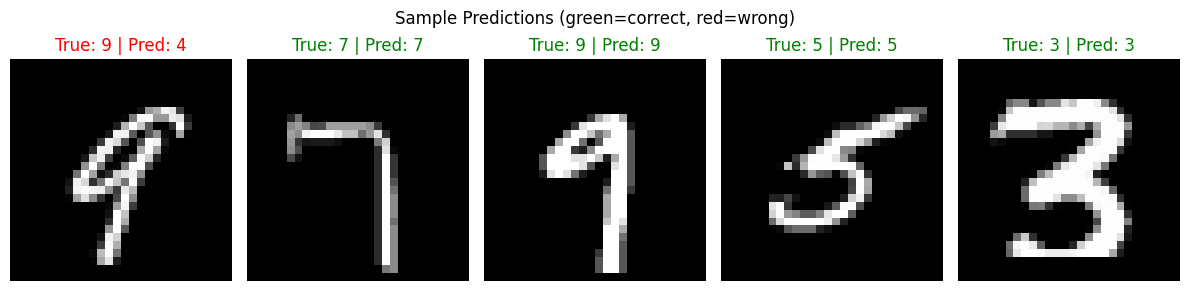

In [8]:
# Step 8) عرض صور + تنبؤات / Visualize predictions
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

fig, axes = plt.subplots(1, 5, figsize=(12, 3))
for i, ax in enumerate(axes):
    ax.imshow(X_test[i].reshape(28, 28), cmap='gray')
    color = 'green' if y_pred[i] == y_test[i] else 'red'
    ax.set_title(f'True: {y_test[i]} | Pred: {y_pred[i]}', color=color)
    ax.axis('off')
plt.suptitle('Sample Predictions (green=correct, red=wrong)')
plt.tight_layout()
plt.show()